# Kuramoto Fully-Connected

In [3]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt
import pandas as pd
import math as math
import scipy.integrate as inte
import time as tim



### Determining order parameter by consistancy equation:

According to the analytical calculation for the Lorentzian frequency distribution: $1 = \lambda/(1+\sqrt{1+(\lambda R)^2}) \implies$
$R = \sqrt{\frac{\lambda-2}{\lambda}}$

In [2]:
def Rtheo(lamb):
    if (lamb<2):
        return 0
    else:
        return np.sqrt((lamb-2)/lamb)

Rtheo = np.vectorize(Rtheo,otypes=[float])

### Numerical calculation

First we create a routine for the Kuramoto model

In [3]:
#def omLtz(N): # using the Lorentzian cumulative distribution for a regular frequency sampling
#    omLtz = np.zeros(N)
#    for i in range(N):
#        omLtz[i] = np.tan(np.pi*(i+0.5-0.5*N)/N)
#    return np.array([omLtz])

In [4]:
#def fKM(lamb,omarr,tharr):
#    N = np.size(tharr)
#    velarr = np.copy(omarr)
    
#    for i in range(N):
#        dvel = 0
#        for j in range(N):
#            dvel = dvel + math.sin(tharr[j]-tharr[i])

#        vel = velarr[i] + lamb*dvel/N
#        velarr[i] = vel
#    return velarr


In [5]:
#def fKM(lamb,omarr,tharr):
#    N = np.size(tharr)
#    adj = np.zeros([N,N])

    
#    for i in range(N):
#        for j in range(i+1,N):
            
#            adj[i,j] = math.sin(tharr[j]-tharr[i])
#            adj[j,i] = - adj[i,j]

#    velarr = omarr + lamb*np.sum(adj,1)/N
    #velarr[i] = vel
#    return velarr

In [6]:
#def fKM(lamb,omarr,tharr):
#    N = np.size(tharr)
#    adj = np.zeros([N,N])

    
#    adj = np.cos(th0).T*np.sin(th0) - np.sin(th0).T*np.cos(th0)

#    velarr = omarr + lamb*np.sum(adj,1)/N
    #velarr[i] = vel
#    return velarr

In [3]:
def Init(N,seed=42):
    rng = np.random.default_rng(seed)
    th0 = np.zeros(N)
    for i in range(N):
        th0[i] = rng.uniform(-np.pi,np.pi)
    return np.array([th0])

def omLtz(N): # using the Lorentzian cumulative distribution for a regular frequency sampling
    omLtz = np.zeros(N)
    for i in range(N):
        omLtz[i] = np.tan(np.pi*(i+0.5-0.5*N)/N)
    return np.array([omLtz])
    
def order(tharr):
    #N = np.size(tharr)
    #print(N)
    #Rx = np.sum(np.cos(tharr))/N
    #Ry = np.sum(np.sin(tharr))/N
    Rx = np.mean(np.cos(tharr))
    Ry = np.mean(np.sin(tharr))
    R = np.sqrt(Rx**2+Ry**2)
    phi = np.asin(Ry/R)
    return (R,phi)

#order = np.vectorize(order)

def fKM(lamb,omarr,tharr):
    N = np.size(tharr)
    R, phi = order(tharr)
    velarr = omarr + lamb*R*np.sin(phi-tharr)
    
    return velarr

In [4]:
def time_interval(dt,tf):
    Nt = int(tf/dt)+1
    time = np.linspace(0,tf,Nt)
    return (time,dt)
    
    
def integ(time,lamb,omarr,thini): #Heun method of integration
    N = np.size(thini)
    timelist, dt = time
    #print(dt)
    Nt = np.size(timelist)
    integ = np.zeros([Nt,2,N])
    #print(integ[0,:,:])
    #print(np.array([thini,fKM(lamb,omarr,thini)]))
    
    integ[0,:,:] = np.array([thini[0],fKM(lamb,omarr,thini)[0]])
    th = thini
    
    
    for i in range(1,Nt):
        velaux = fKM(lamb,omarr,th)
        thaux = th + dt*velaux
        vel = (fKM(lamb,omarr,th)+fKM(lamb,omarr,thaux))/2.
        th = np.remainder(th + dt*vel,2*np.pi) -np.pi

        integ[i,:,:] = np.array([th[0],velaux[0]])
    return integ
    

In [4]:
def Init(N,seed=42):
    rng = np.random.default_rng(seed)
    th0 = np.zeros(N)
    for i in range(N):
        th0[i] = rng.uniform(-np.pi,np.pi)
    return np.array([th0])

def omLtz(N): # using the Lorentzian cumulative distribution for a regular frequency sampling
    omLtz = np.zeros(N)
    for i in range(N):
        omLtz[i] = np.tan(np.pi*(i+0.5-0.5*N)/N)
    return np.array([omLtz])
    
def order(tharr):
    #N = np.size(tharr)
    #print(N)
    #Rx = np.sum(np.cos(tharr))/N
    #Ry = np.sum(np.sin(tharr))/N
    Rx = np.mean(np.cos(tharr))
    Ry = np.mean(np.sin(tharr))
    R = np.sqrt(Rx**2+Ry**2)
    phi = np.asin(Ry/R)
    return (R,phi)

#order = np.vectorize(order)

def fKM(lamb,omarr,tharr):
    N = np.size(tharr)
    R, phi = order(tharr)
    velarr = omarr + lamb*R*np.sin(phi-tharr)
    
    return velarr

def time_interval(dt,tf):
    Nt = int(tf/dt)+1
    time = np.linspace(0,tf,Nt)
    return (time,dt)
    
    
def integ(time,lamb,omarr,thini): #Heun method of integration
    N = np.size(thini)
    timelist, dt = time
    #print(dt)
    Nt = np.size(timelist)
    integ = np.zeros([Nt,2,N])
    #print(integ[0,:,:])
    #print(np.array([thini,fKM(lamb,omarr,thini)]))
    
    integ[0,:,:] = np.array([thini[0],fKM(lamb,omarr,thini)[0]])
    th = thini
    
    
    for i in range(1,Nt):
        velaux = fKM(lamb,omarr,th)
        thaux = th + dt*velaux
        vel = (fKM(lamb,omarr,th)+fKM(lamb,omarr,thaux))/2.
        th = np.remainder(th + dt*vel,2*np.pi) -np.pi

        integ[i,:,:] = np.array([th[0],velaux[0]])
    return integ
    

In [35]:
def Init(N,seed=42):
    rng = np.random.default_rng(seed)
    th0 = np.zeros(N)
    for i in range(N):
        th0[i] = rng.uniform(-np.pi,np.pi)
    return np.array([th0])

def omLtz(N): # using the Lorentzian cumulative distribution for a regular frequency sampling
    omLtz = np.zeros(N)
    for i in range(N):
        omLtz[i] = np.tan(np.pi*(i+0.5-0.5*N)/N)
    return np.array([omLtz])
    
def order(tharr):
    #N = np.size(tharr)
    #print(N)
    #Rx = np.sum(np.cos(tharr))/N
    #Ry = np.sum(np.sin(tharr))/N
    Rx = np.mean(np.cos(tharr))
    Ry = np.mean(np.sin(tharr))
    R = np.sqrt(Rx**2+Ry**2)
    phi = np.asin(Ry/R)
    return (R,phi)

#order = np.vectorize(order)

def fKM(lamb,tharr):
    N = np.size(tharr)
    #R, phi = order(tharr)
    Rx = np.mean(np.cos(tharr))
    Ry = np.mean(np.sin(tharr))
    R = np.sqrt(Rx**2+Ry**2)
    phi = np.asin(Ry/R)
    velarr = lamb*R*np.sin(phi-tharr)
    
    return velarr

def time_interval(dt,tf):
    Nt = int(tf/dt)+1
    time = np.linspace(0,tf,Nt)
    return (time,dt)
    
    
def integ(time,lamb,omarr,thini): #Heun method of integration
    N = np.size(thini)
    timelist, dt = time
    #print(dt)
    Nt = np.size(timelist)
    integ = np.zeros([Nt,2,N])
    #print(integ[0,:,:])
    #print(np.array([thini,fKM(lamb,omarr,thini)]))
    
    integ[0,:,:] = np.array([thini[0],(omarr+fKM(lamb,thini))[0]])
    th = thini
    
    
    for i in range(1,Nt):
        velaux = omarr + fKM(lamb,th)
        #thaux = th + dt*velaux
        #vel = (fKM(lamb,omarr,th)+fKM(lamb,omarr,th + dt*velaux))/2.
        th = np.remainder(th + dt*(omarr + 0.5*(fKM(lamb,th)+fKM(lamb,th + dt*velaux))),2*np.pi) 

        integ[i,:,:] = np.array([th[0],velaux[0]])
    return integ
    

In [100]:
N = 10000
omlist = omLtz(N)
th0 = Init(N,30)
lamb = 2.3
time = time_interval(0.05,500)
Nt = np.size(time[0])

f1 = fKM(lamb,th0)
#result = integ(time,lamb,omlist,th0)

In [101]:
start_time = tim.perf_counter()

result = integ(time,lamb,omlist,th0)

end_time = tim.perf_counter()
elapsed_time = end_time - start_time
print(f"Elapsed execution time: {elapsed_time:.6f} seconds")

Elapsed execution time: 20.085438 seconds


In [102]:
f1

array([[ 0.00555971,  0.01967519, -0.01139696, ..., -0.01924256,
         0.0028299 , -0.01916238]], shape=(1, 10000))

In [103]:
result[-1,0,:]

array([1.13636839, 2.05752317, 0.97302687, ..., 5.18160935, 5.02550171,
       0.21714164], shape=(10000,))

In [104]:
result[1000,:,:][0]

array([0.64076618, 5.82371972, 3.76175972, ..., 2.56256276, 1.00114438,
       0.7025676 ], shape=(10000,))

In [105]:
np.histogram(result[1000,0,:],15)

(array([ 638,  896, 1224, 1411, 1237,  877,  641,  506,  392,  345,  296,
         283,  353,  407,  494]),
 array([7.34472777e-04, 4.19528913e-01, 8.38323353e-01, 1.25711779e+00,
        1.67591223e+00, 2.09470667e+00, 2.51350111e+00, 2.93229555e+00,
        3.35108999e+00, 3.76988443e+00, 4.18867887e+00, 4.60747331e+00,
        5.02626775e+00, 5.44506219e+00, 5.86385663e+00, 6.28265107e+00]))

In [106]:
final = result[-1,:,:]
final

array([[ 1.13636839e+00,  2.05752317e+00,  9.73026869e-01, ...,
         5.18160935e+00,  5.02550171e+00,  2.17141637e-01],
       [-6.36566568e+03, -2.12200889e+03, -1.27354166e+03, ...,
         1.27305599e+03,  2.12281631e+03,  6.36554051e+03]],
      shape=(2, 10000))

In [107]:
np.arange(10)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

(0.0, 6.28)

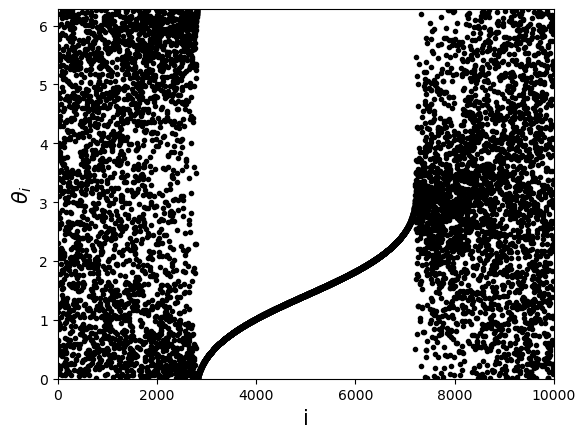

In [108]:
final = result[-1,:,:]
index = np.arange(N)

plt.scatter(index,final[0],marker='.',color='black')
plt.ylabel(r"$\theta_i$",size=15)
plt.xlabel(r"i",size=15)
plt.xlim(0,N)
plt.ylim(0,6.28)
#plt.savefig("KuramotoSolution-theta.pdf")

In [112]:
with open('KuramotoSolution.dat', 'w') as f:
    f.write("i theta vel\n")
    for i in range(N):
        f.write(str(i+1)+" "+str(final[0,i])+" "+str(final[1,i])+"\n")

Text(0.5, 0, 'i')

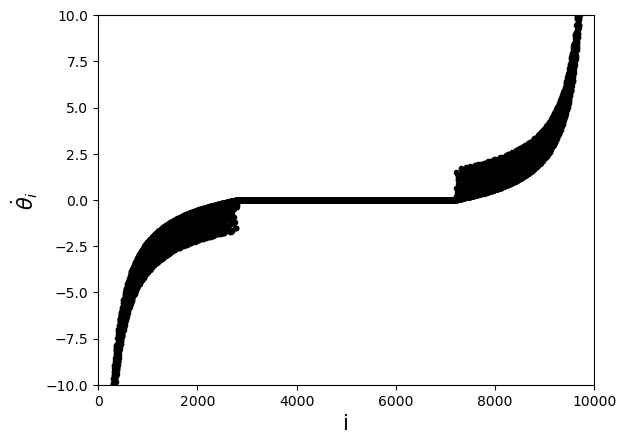

In [109]:
plt.scatter(index,final[1],marker='.',color='black')
#plt.yscale('log')
plt.ylim(-10,10)
plt.xlim(0,N)
plt.ylabel(r"$\dot{\theta}_i$",size=15)
plt.xlabel(r"i",size=15)
#plt.savefig("KuramotoSolution-vel.pdf")

In [110]:
Rlist = np.zeros(Nt)
philist = np.zeros(Nt)

for i in range(Nt):
    Rlist[i], philist[i] = order(result[i])


#Rlist, philist = order(result[-1,0,:])

In [111]:
Rlist[-1]

np.float64(0.3258803403252318)

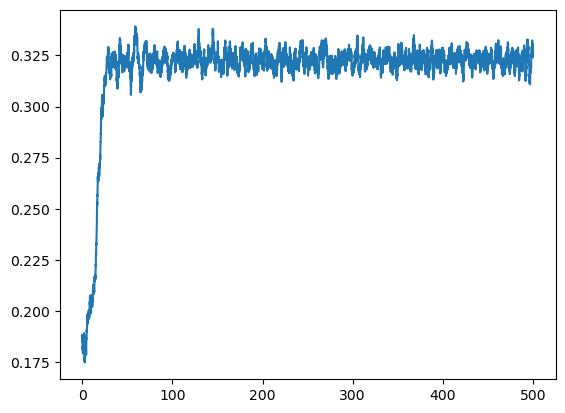

In [112]:
plt.plot(time[0],Rlist)

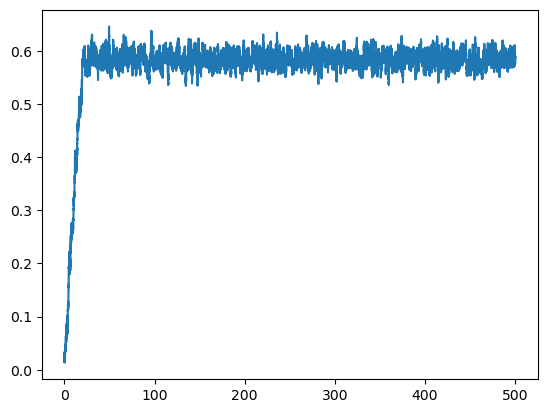

In [99]:
plt.plot(time[0],np.abs(philist))

In [38]:
#Rlist[-1000:-1]
Remp = np.mean(Rlist[-100:-1])
print(lamb,Remp,Rtheo(lamb))

2.5 0.3559934464466367 0.4472135954999579


## Critical coupling

In [22]:
Rtheo(lamb)

np.float64(0.6546536707079771)

In [54]:
N = 10000
omlist = omLtz(N)
th0 = Init(N,10)
time = time_interval(0.01,50)
Nt = np.size(time[0])

Nlamb = 40
lamblist = np.linspace(0.1,10,Nlamb)
Rlist = np.zeros(Nlamb)



In [55]:
for i in range(Nlamb):
    result = integ(time,lamblist[i],omlist,th0)
    R, phi = order(result[-1,0,:])
    Rlist[i] = R
#result = integ(time,lamb,omlist,th0)

Text(0.5, 0, '$\\lambda$')

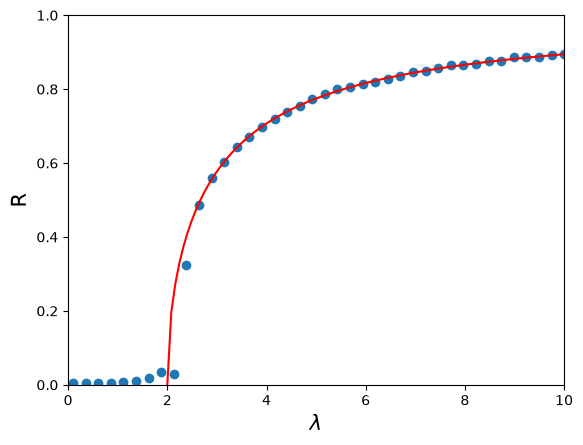

In [69]:

plt.scatter(lamblist,Rlist)
plt.plot(np.linspace(2,10,100),Rtheo(np.linspace(2,10,100)),color='red')
plt.ylim(0,1)
plt.xlim(0,10)
plt.ylabel('R',size=15)
plt.xlabel(r"$\lambda$",size=15)

#plt.savefig("Kuramoto-fully-transition.pdf")

In [107]:
with open('Kuramoto.dat', 'w') as f:
    f.write("\lambda R\n")
    for i in range(Nlamb):
        f.write(str(lamblist[i])+" "+str(Rlist[i])+"\n")


In [106]:
lamblist

array([ 0.1       ,  0.35384615,  0.60769231,  0.86153846,  1.11538462,
        1.36923077,  1.62307692,  1.87692308,  2.13076923,  2.38461538,
        2.63846154,  2.89230769,  3.14615385,  3.4       ,  3.65384615,
        3.90769231,  4.16153846,  4.41538462,  4.66923077,  4.92307692,
        5.17692308,  5.43076923,  5.68461538,  5.93846154,  6.19230769,
        6.44615385,  6.7       ,  6.95384615,  7.20769231,  7.46153846,
        7.71538462,  7.96923077,  8.22307692,  8.47692308,  8.73076923,
        8.98461538,  9.23846154,  9.49230769,  9.74615385, 10.        ])